In [ ]:
from google.colab import files
uploaded = files.upload()

Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv


Dataset loaded successfully!
Shape of dataset: (30000, 25)

First 5 rows:
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4 

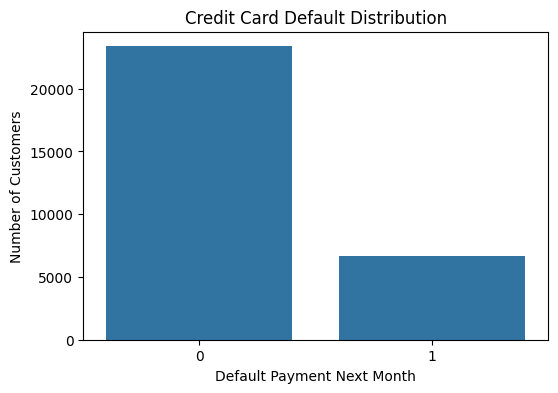

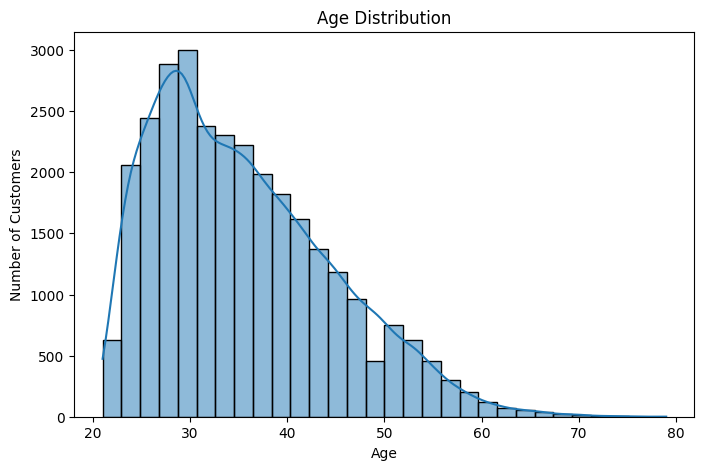

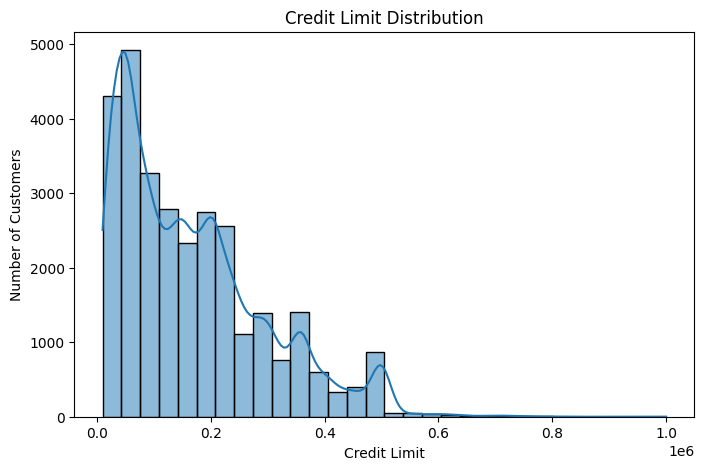

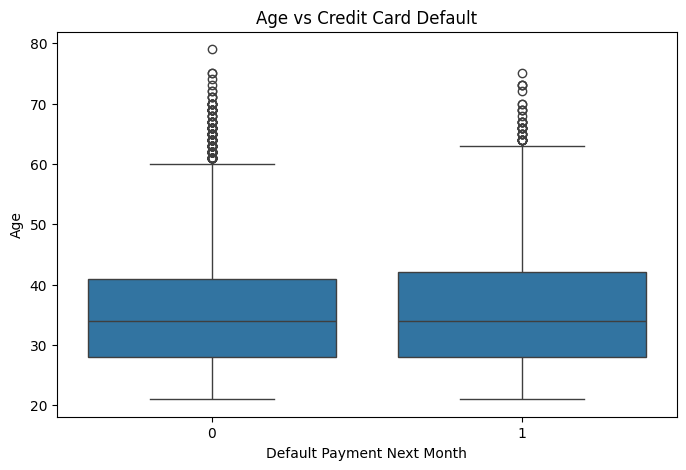

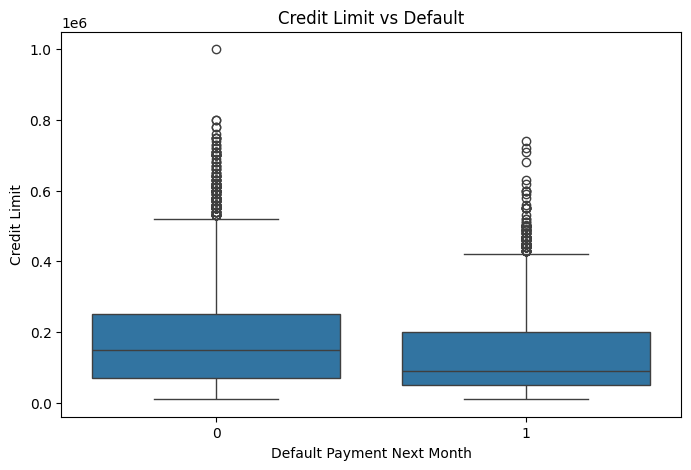

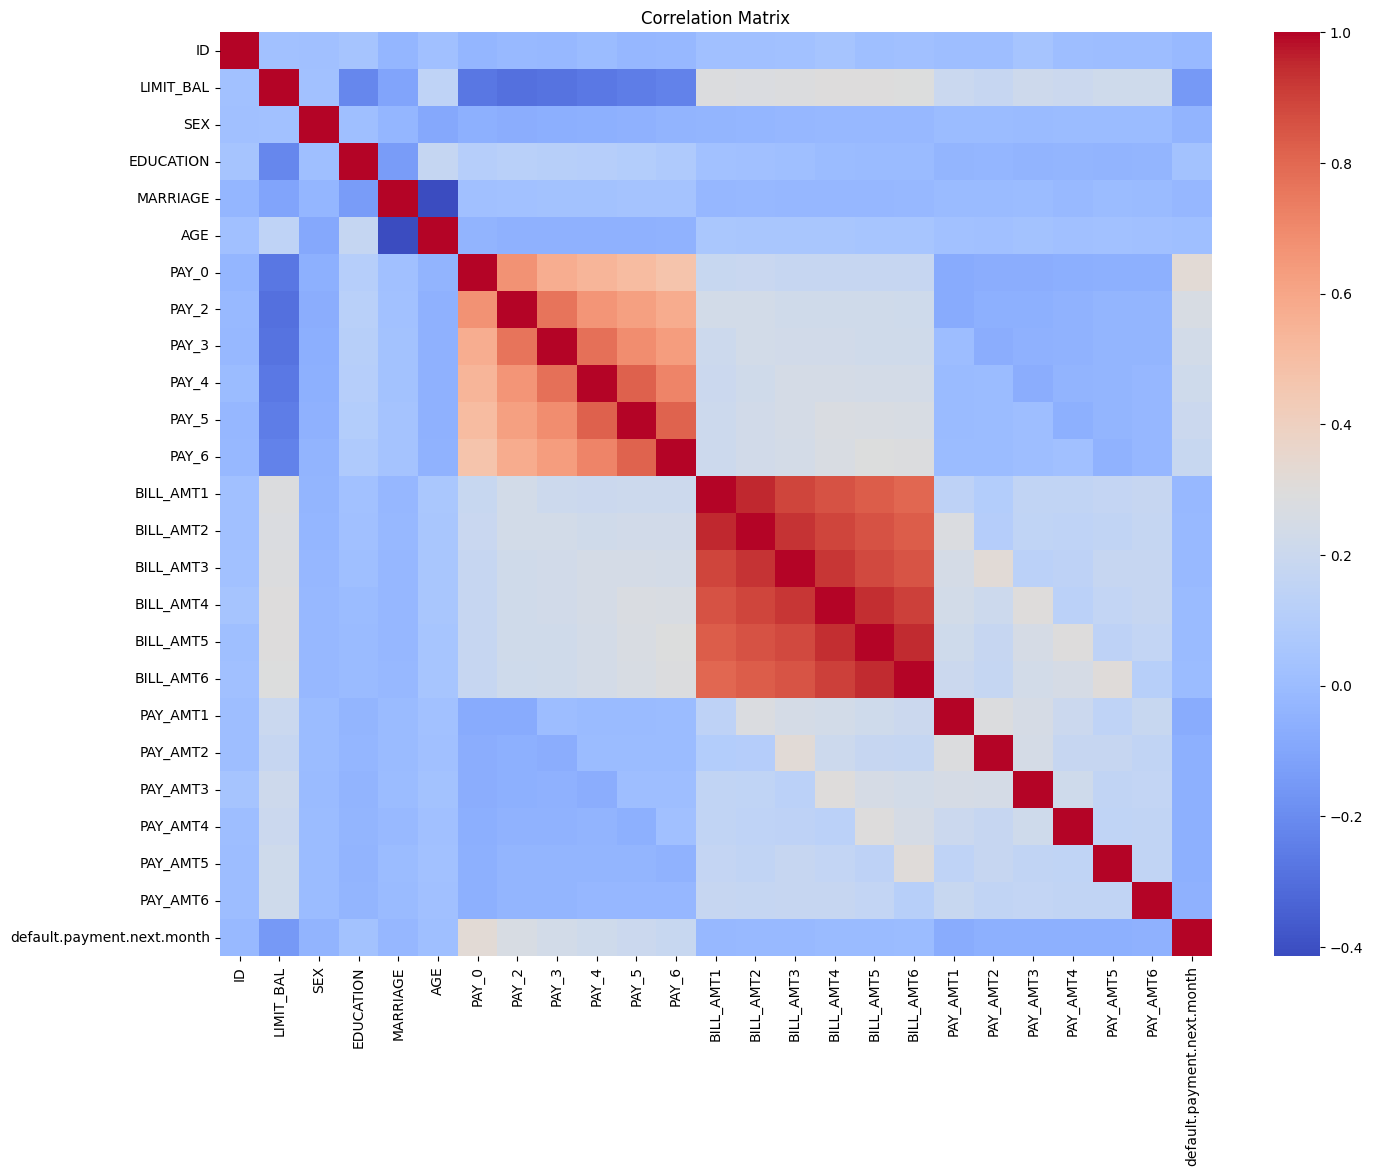


Correlation with Target:
default.payment.next.month    1.000000
PAY_0                         0.324794
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
EDUCATION                     0.028006
AGE                           0.013890
BILL_AMT6                    -0.005372
BILL_AMT5                    -0.006760
BILL_AMT4                    -0.010156
ID                           -0.013952
BILL_AMT3                    -0.014076
BILL_AMT2                    -0.014193
BILL_AMT1                    -0.019644
MARRIAGE                     -0.024339
SEX                          -0.039961
PAY_AMT6                     -0.053183
PAY_AMT5                     -0.055124
PAY_AMT3                     -0.056250
PAY_AMT4                     -0.056827
PAY_AMT2                     -0.058579
PAY_AMT1                     -0.072929
LIMIT_BAL                    -0.153520

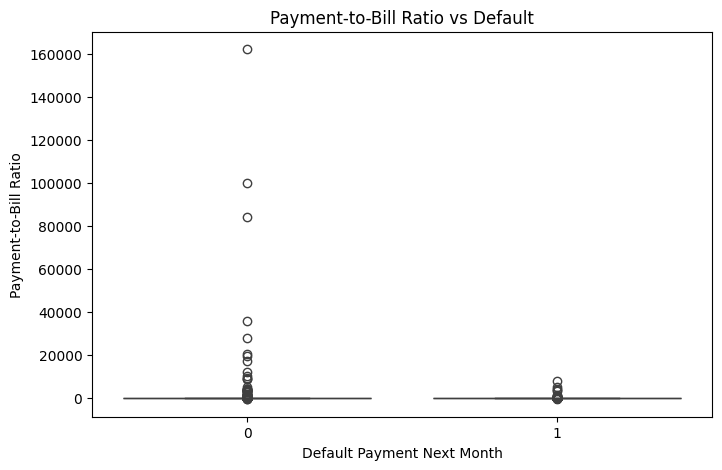

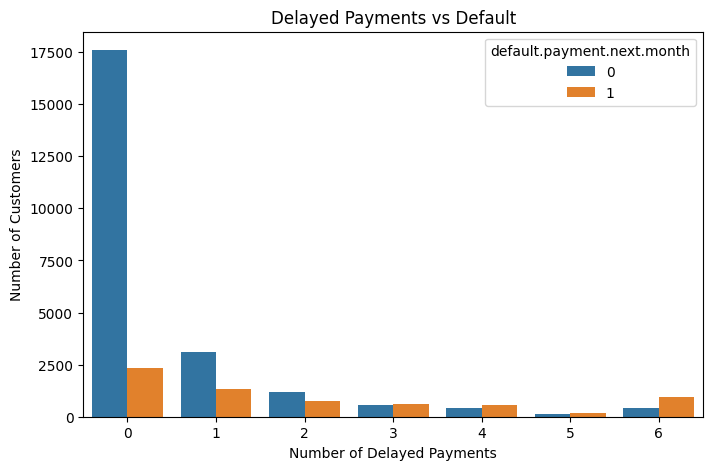

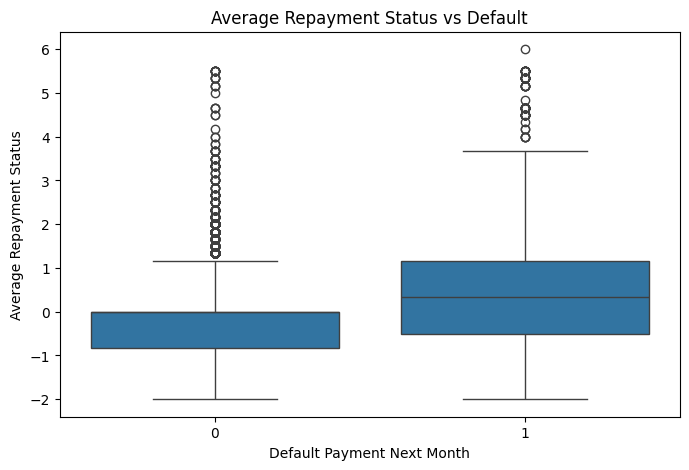


Final Dataset Shape: (30000, 33)

Final Columns:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month', 'TOTAL_BILL_AMT', 'AVG_BILL_AMT', 'TOTAL_PAYMENT_AMT', 'AVG_PAYMENT_AMT', 'PAYMENT_BILL_RATIO', 'AVG_REPAYMENT_STATUS', 'NUM_DELAYED_PAYMENTS', 'AGE_GROUP']

Training Data Shape: (24000, 35)
Testing Data Shape: (6000, 35)

Model training completed!

Model Accuracy: 0.8096666666666666

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      4673
           1       0.66      0.29      0.40      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.62      0.65      6000
weighted avg       0.79      0.81      0.78      6000



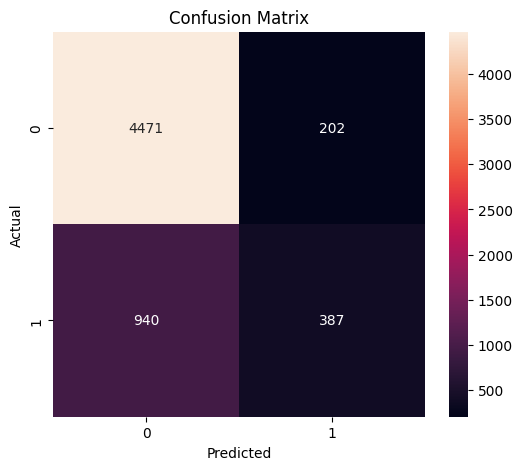

In [ ]:
# ============================================================
# FEATURE ENGINEERING AND EDA PROJECT
# UCI CREDIT CARD DEFAULT DATASET
# ============================================================

# -------------------- 1. IMPORT LIBRARIES --------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# -------------------- 2. LOAD DATASET ------------------------

df = pd.read_csv("UCI_Credit_Card.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

print("\nFirst 5 rows:")
print(df.head())


# -------------------- 3. BASIC INFORMATION ------------------

print("\nDataset Information:")
df.info()

print("\nColumn Names:")
print(df.columns.tolist())

print("\nStatistical Summary:")
print(df.describe())


# -------------------- 4. MISSING VALUES ----------------------

print("\nMissing Values:")
print(df.isnull().sum())


# -------------------- 5. DUPLICATE VALUES --------------------

print("\nNumber of Duplicate Rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


# -------------------- 6. TARGET VARIABLE ---------------------

target = "default.payment.next.month"

print("\nTarget Variable Distribution:")
print(df[target].value_counts())


# -------------------- 7. TARGET VISUALIZATION ----------------

plt.figure(figsize=(6, 4))

sns.countplot(x=target, data=df)

plt.title("Credit Card Default Distribution")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Number of Customers")

plt.show()


# -------------------- 8. AGE DISTRIBUTION --------------------

plt.figure(figsize=(8, 5))

sns.histplot(df["AGE"], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()


# -------------------- 9. CREDIT LIMIT DISTRIBUTION -----------

plt.figure(figsize=(8, 5))

sns.histplot(df["LIMIT_BAL"], bins=30, kde=True)

plt.title("Credit Limit Distribution")
plt.xlabel("Credit Limit")
plt.ylabel("Number of Customers")

plt.show()


# -------------------- 10. AGE VS DEFAULT ---------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=target,
    y="AGE",
    data=df
)

plt.title("Age vs Credit Card Default")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Age")

plt.show()


# -------------------- 11. CREDIT LIMIT VS DEFAULT ------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=target,
    y="LIMIT_BAL",
    data=df
)

plt.title("Credit Limit vs Default")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Credit Limit")

plt.show()


# -------------------- 12. CORRELATION MATRIX -----------------

correlation = df.corr(numeric_only=True)

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()


# -------------------- 13. CORRELATION WITH TARGET ------------

print("\nCorrelation with Target:")

target_correlation = correlation[target].sort_values(
    ascending=False
)

print(target_correlation)


# ============================================================
#                 FEATURE ENGINEERING
# ============================================================


# -------------------- 14. BILL AMOUNT FEATURES --------------

bill_columns = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6"
]

# Total bill amount
df["TOTAL_BILL_AMT"] = df[bill_columns].sum(axis=1)

# Average bill amount
df["AVG_BILL_AMT"] = df[bill_columns].mean(axis=1)


# -------------------- 15. PAYMENT FEATURES ------------------

payment_columns = [
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

# Total payment amount
df["TOTAL_PAYMENT_AMT"] = df[payment_columns].sum(axis=1)

# Average payment amount
df["AVG_PAYMENT_AMT"] = df[payment_columns].mean(axis=1)


# -------------------- 16. PAYMENT-BILL RATIO -----------------

df["PAYMENT_BILL_RATIO"] = (
    df["TOTAL_PAYMENT_AMT"] /
    (df["TOTAL_BILL_AMT"] + 1)
)


# -------------------- 17. REPAYMENT FEATURES ----------------

pay_status_columns = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

# Average repayment status
df["AVG_REPAYMENT_STATUS"] = (
    df[pay_status_columns].mean(axis=1)
)

# Number of delayed payments
df["NUM_DELAYED_PAYMENTS"] = (
    df[pay_status_columns] > 0
).sum(axis=1)


# -------------------- 18. AGE GROUP --------------------------

df["AGE_GROUP"] = pd.cut(
    df["AGE"],
    bins=[0, 25, 35, 45, 55, 100],
    labels=[
        "Young",
        "Adult",
        "Middle_Aged",
        "Senior",
        "Very_Senior"
    ]
)


# -------------------- 19. DISPLAY NEW FEATURES --------------

print("\nNewly Created Features:")

new_features = [
    "TOTAL_BILL_AMT",
    "TOTAL_PAYMENT_AMT",
    "AVG_BILL_AMT",
    "AVG_PAYMENT_AMT",
    "PAYMENT_BILL_RATIO",
    "AVG_REPAYMENT_STATUS",
    "NUM_DELAYED_PAYMENTS",
    "AGE_GROUP"
]

print(df[new_features].head())


# -------------------- 20. PAYMENT RATIO VS DEFAULT -----------

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=target,
    y="PAYMENT_BILL_RATIO",
    data=df
)

plt.title("Payment-to-Bill Ratio vs Default")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Payment-to-Bill Ratio")

plt.show()


# -------------------- 21. DELAYED PAYMENTS VS DEFAULT --------

plt.figure(figsize=(8, 5))

sns.countplot(
    x="NUM_DELAYED_PAYMENTS",
    hue=target,
    data=df
)

plt.title("Delayed Payments vs Default")
plt.xlabel("Number of Delayed Payments")
plt.ylabel("Number of Customers")

plt.show()


# -------------------- 22. REPAYMENT STATUS VS DEFAULT --------

plt.figure(figsize=(8, 5))

sns.boxplot(
    x=target,
    y="AVG_REPAYMENT_STATUS",
    data=df
)

plt.title("Average Repayment Status vs Default")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Average Repayment Status")

plt.show()


# -------------------- 23. FINAL DATASET -----------------------

print("\nFinal Dataset Shape:", df.shape)

print("\nFinal Columns:")
print(df.columns.tolist())


# ============================================================
#              MACHINE LEARNING PREPARATION
# ============================================================


# -------------------- 24. SEPARATE X AND Y -------------------

X = df.drop(target, axis=1)

y = df[target]


# -------------------- 25. ONE-HOT ENCODING -------------------

X = pd.get_dummies(
    X,
    columns=["AGE_GROUP"],
    drop_first=True
)


# -------------------- 26. TRAIN TEST SPLIT -------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


# -------------------- 27. FEATURE SCALING --------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# -------------------- 28. LOGISTIC REGRESSION ----------------

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

print("\nModel training completed!")


# -------------------- 29. PREDICTION --------------------------

y_pred = model.predict(X_test_scaled)


# -------------------- 30. ACCURACY ----------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nModel Accuracy:", accuracy)


# -------------------- 31. CLASSIFICATION REPORT -------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# -------------------- 32. CONFUSION MATRIX -------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()